In [13]:
###  IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
###  DATA GENERATION & PREPARATION
np.random.seed(42)
n_rows = 10000

# Generating synthetic features based on BigMart patterns
mrp = np.random.uniform(30, 260, n_rows)
sales = (mrp * 15) + np.random.normal(0, 200, n_rows)

data = {
    # Item_Weight: Includes 20% missing values to simulate real-world sparsity
    'Item_Weight': [np.random.uniform(5, 20) if np.random.rand() > 0.2 else np.nan for _ in range(n_rows)],
    'Item_Fat_Content': np.random.choice(['Low Fat', 'Regular', 'LF', 'reg'], n_rows),
    'Item_MRP': mrp,
    'Item_Outlet_Sales': sales,
    'Outlet_Size': np.random.choice(['Small', 'Medium', 'High', 'nan'], n_rows)
}

df = pd.DataFrame(data)

In [15]:
### Data Exploration

df.head()

,Item_Weight,Item_Fat_Content,Item_MRP,Item_Outlet_Sales,Outlet_Size
0,6.965428,Regular,116.144227,1444.591069,Small
1,8.927323,Low Fat,248.664290,3504.927137,High
2,19.317440,Regular,198.358607,3053.142881,nan
3,18.899741,Low Fat,167.691451,2280.597105,Small
4,15.918164,Low Fat,65.884287,1210.791171,Medium


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Item_Weight        8002 non-null   float64
 1   Item_Fat_Content   10000 non-null  object 
 2   Item_MRP           10000 non-null  float64
 3   Item_Outlet_Sales  10000 non-null  float64
 4   Outlet_Size        10000 non-null  object 
dtypes: float64(3), object(2)
memory usage: 390.8+ KB


In [17]:
df.isnull().sum()

Item_Weight          1998
Item_Fat_Content        0
Item_MRP                0
Item_Outlet_Sales       0
Outlet_Size             0
dtype: int64

In [18]:
print(df['Item_Fat_Content'].value_counts())
#print(df['Item_Type'].value_counts())
print(df['Outlet_Size'].value_counts())


Item_Fat_Content
Low Fat    2559
Regular    2506
reg        2478
LF         2457
Name: count, dtype: int64
Outlet_Size
Medium    2536
Small     2496
nan       2491
High      2477
Name: count, dtype: int64


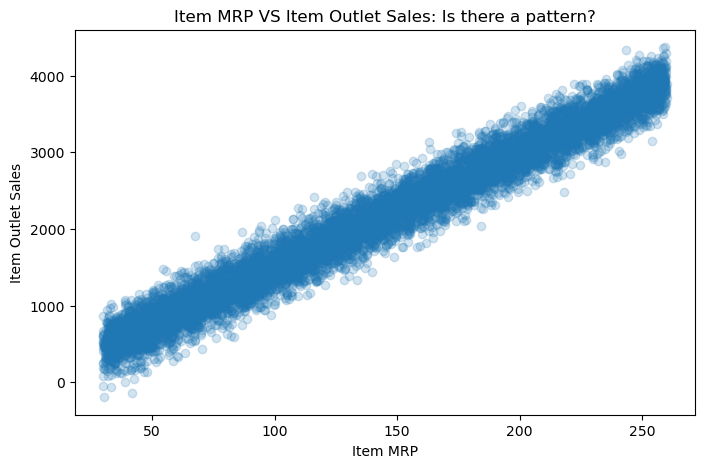

In [19]:
## Item_MRP VS Item_Outlet_Sales
#Trying to uncover a pattern

plt.figure(figsize=(8,5))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.2)
plt.xlabel('Item MRP')
plt.ylabel('Item Outlet Sales')
plt.title('Item MRP VS Item Outlet Sales: Is there a pattern?')
plt.show()

In [20]:
###  DATA CLEANING
# Standardizing Item_Fat_Content to prevent redundant categories (e.g., 'LF' vs 'Low Fat')
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'reg': 'Regular'})

# Treating missing 'Outlet_Size' as a distinct 'Unknown' category rather than dropping rows
df['Outlet_Size'] = df['Outlet_Size'].astype(str).replace('nan', 'Unknown')

# Filling missing weights with the Median to ensure a robust center point unaffected by outliers
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].median())

In [21]:
###  FEATURE ENGINEERING & SPLITTING
# Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
X = pd.get_dummies(df.drop('Item_Outlet_Sales', axis=1))
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [23]:
### TRAINING THE RANDOM FOREST MODEL
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, random_state=42)

In [24]:
### PREDICTION
y_pred = rf.predict(X_test)

In [25]:
### METRICS
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'R2 Score: {r2:.4f}')
print(f'Root Mean Squared Error: ${rmse:.2f}')

R2 Score: 0.9592
Root Mean Squared Error: $202.74


In [26]:
### HYPERPARAMETER TUNING
# Define the parameter grid for GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}


grid_search = GridSearchCV(estimator=rf, cv=5, param_grid=param_grid, scoring='r2', n_jobs=-1)
# Cross-validation ensures the model generalizes well to unseen data
grid_search.fit(X_train, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score (R2): {grid_search.best_score_:.4f}')

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score (R2): 0.9600


In [31]:
## Final Metrics/Evaluation

best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
final_r2 = r2_score(y_test, y_pred_tuned)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print('Old R2 Score: 0.9592')
print(f'Final R2 Score: {final_r2:.4f}')
print(f'Root Mean Squared Error: ${final_rmse:.2f}')

Old R2 Score: 0.9592
Final R2 Score: 0.9611
Root Mean Squared Error: $198.05


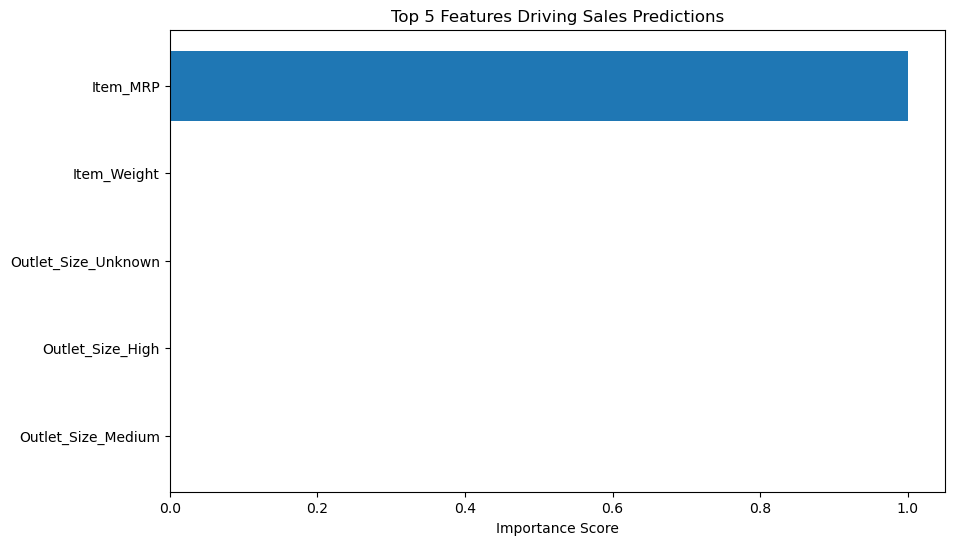

In [28]:
###  FEATURE IMPORTANCE VISUALIZATION
importance = best_rf.feature_importances_
feat_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'][:5], feat_importance_df['Importance'][:5])
plt.gca().invert_yaxis()
plt.title('Top 5 Features Driving Sales Predictions')
plt.xlabel('Importance Score')
plt.show()

In [29]:
## Saving the model

import joblib

joblib.dump(best_rf, 'bigmart_sales_model.pkl')

['bigmart_sales_model.pkl']